# Mass Flux Oscillation

In [62]:
# Set up local project directory path
from pathlib import Path
from tqdm.notebook import tqdm
import sys

project_src = Path('../src').resolve().as_posix()
sys.path.insert(0, project_src)

try:
    import lib.config
except Exception:
    raise Exception("Issue with dynamic import")

# config = lib.config.read_config()
# pwd = Path(config['pwd'])
# case = Path(config['case'])

In [63]:
# Import modules needed for the rest of the notebook
import numpy as np
import xarray as xr
import pandas as pd

import sklearn.preprocessing as skl_prep
from statsmodels.nonparametric import smoothers_lowess as sl

# Pytorch + GP
import torch, gpytorch
from gpytorch.priors import NormalPrior, UniformPrior

In [64]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [65]:
# CUDA setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

if device.type == 'cuda':
    print(f"Using {torch.cuda.get_device_name(0)}")
else:
    print(f"Using {device}")

Using mps


In [66]:
import matplotlib as mpl
from matplotlib import pyplot as plt

import seaborn as sns

sns.set_context('notebook')
sns.set_style('ticks', 
    {
        'axes.grid': True, 
        'axes.linewidth': '1',
        'xtick.labelsize' : 12,
        'ytick.labelsize' : 12,
        'grid.color': '0.5',
        'grid.linestyle': u':',
        'legend.frameon': True,
    })
xkcd = sns.xkcd_rgb


rc_opt = {
    "figure.dpi": 300,
    "font.family": "serif",
    "font.size": 15,
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{libertine} \usepackage[libertine]{newtxmath}",
}
mpl.rcParams.update(rc_opt)

In [67]:
p = Path("../nc/CGILS_25m_1s.nc")

df = xr.open_dataset(p)
df

<xarray.Dataset> Size: 929MB
Dimensions:     (z: 256, time: 1440)
Coordinates:
  * z           (z) float32 1kB 12.5 37.5 62.5 ... 4.039e+04 4.119e+04 4.2e+04
  * time        (time) float32 6kB 196.0 196.0 196.0 196.0 ... 197.0 197.0 197.0
Data variables: (12/712)
    p           (z) float32 1kB ...
    SST         (time) float32 6kB ...
    Ps          (time) float32 6kB ...
    CLDSHD      (time) float32 6kB ...
    AREAPREC    (time) float32 6kB ...
    CLD245      (time) float32 6kB ...
    ...          ...
    EQROMCOR    (time, z) float32 1MB ...
    DQROMCOR    (time, z) float32 1MB ...
    ETROMCOR    (time, z) float32 1MB ...
    DTROMCOR    (time, z) float32 1MB ...
    EWROMCOR    (time, z) float32 1MB ...
    DWROMCOR    (time, z) float32 1MB ...
Attributes:
    SAM version:  
    caseid:       25m_1s

In [68]:
y = np.array(np.nanmean(df.MFCOR.T, axis=0)[720:1440])
x = np.arange(len(y))

x_full = torch.tensor(x[:], dtype=torch.double)
y_full = torch.tensor(y[:], dtype=torch.double)

x_tr = torch.tensor(x[:600], dtype=torch.double)
y_tr = torch.tensor(y[:600], dtype=torch.double)

 The following plot shows the timeseries of total mass flux. Again, it looks very noisy and the oscillatory behaviour is not evident at all. The workflow remains exactly the same as the cloud size distribution, so I will skip the comments.

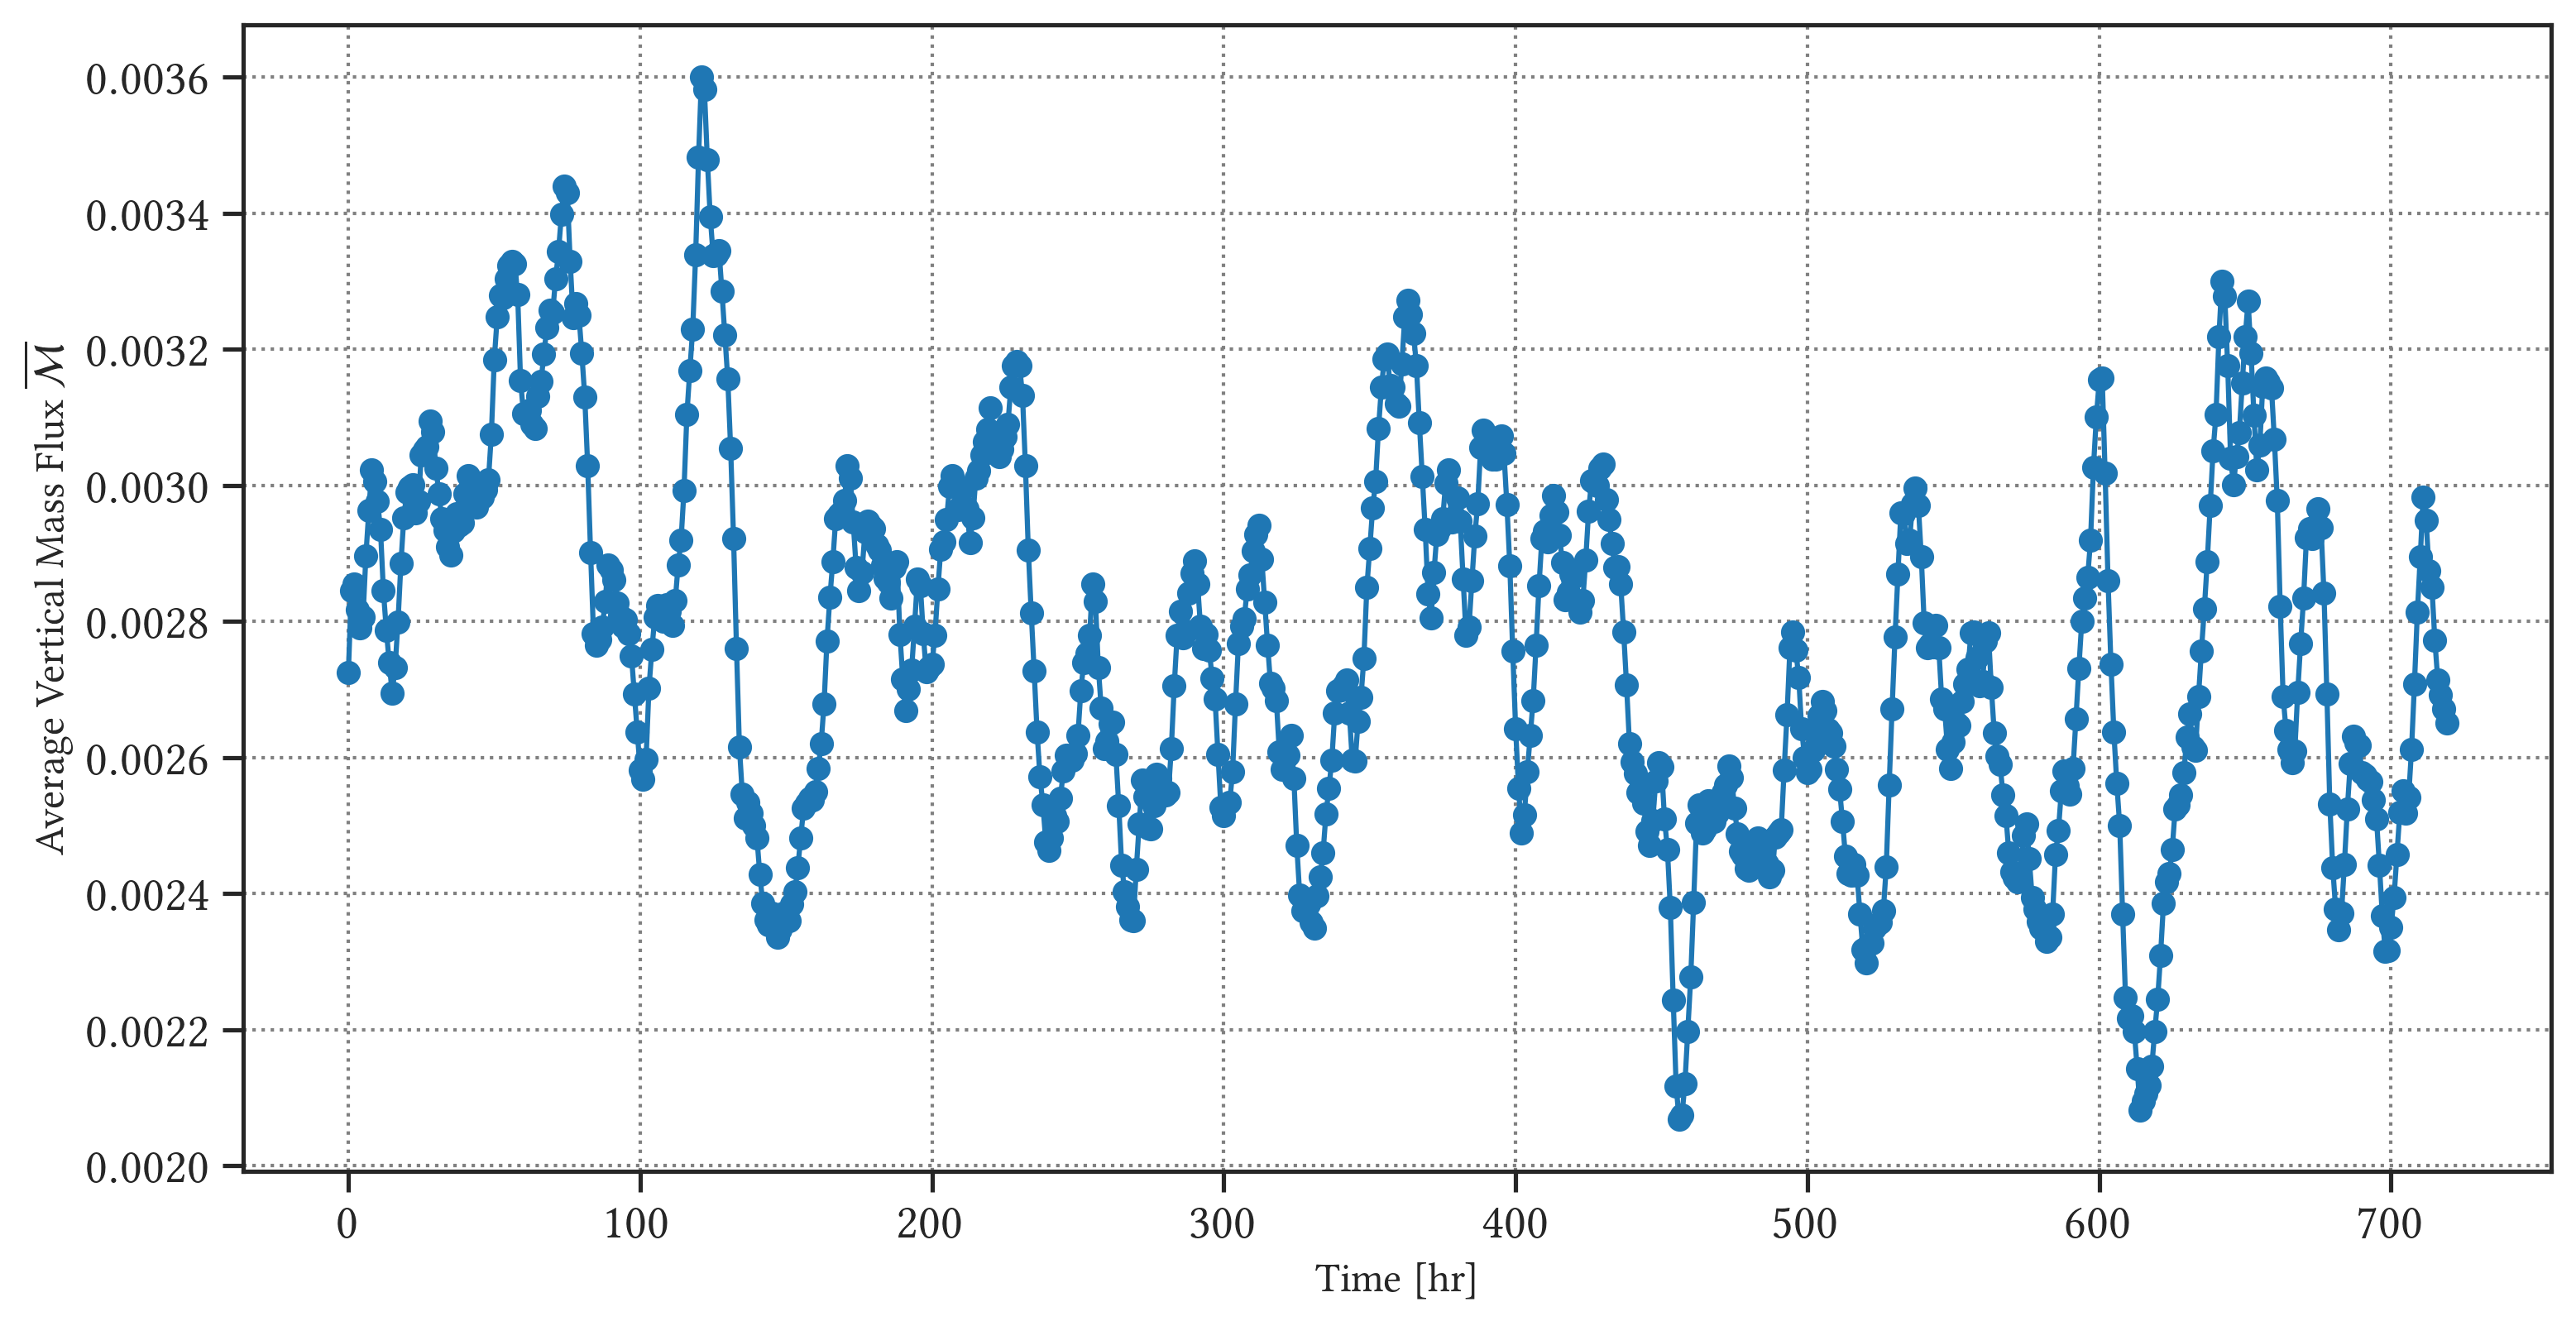

In [69]:
# Plot
fig, ax = plt.subplots(1, 1, figsize = (12, 6))
ax.plot(x_full, y_full, 'o-')

ax.set_xlabel("Time [hr]")
ax.set_ylabel("Average Vertical Mass Flux $\overline{\mathcal{M}}$")

ax.tick_params(axis="both", which="major", labelsize=14)

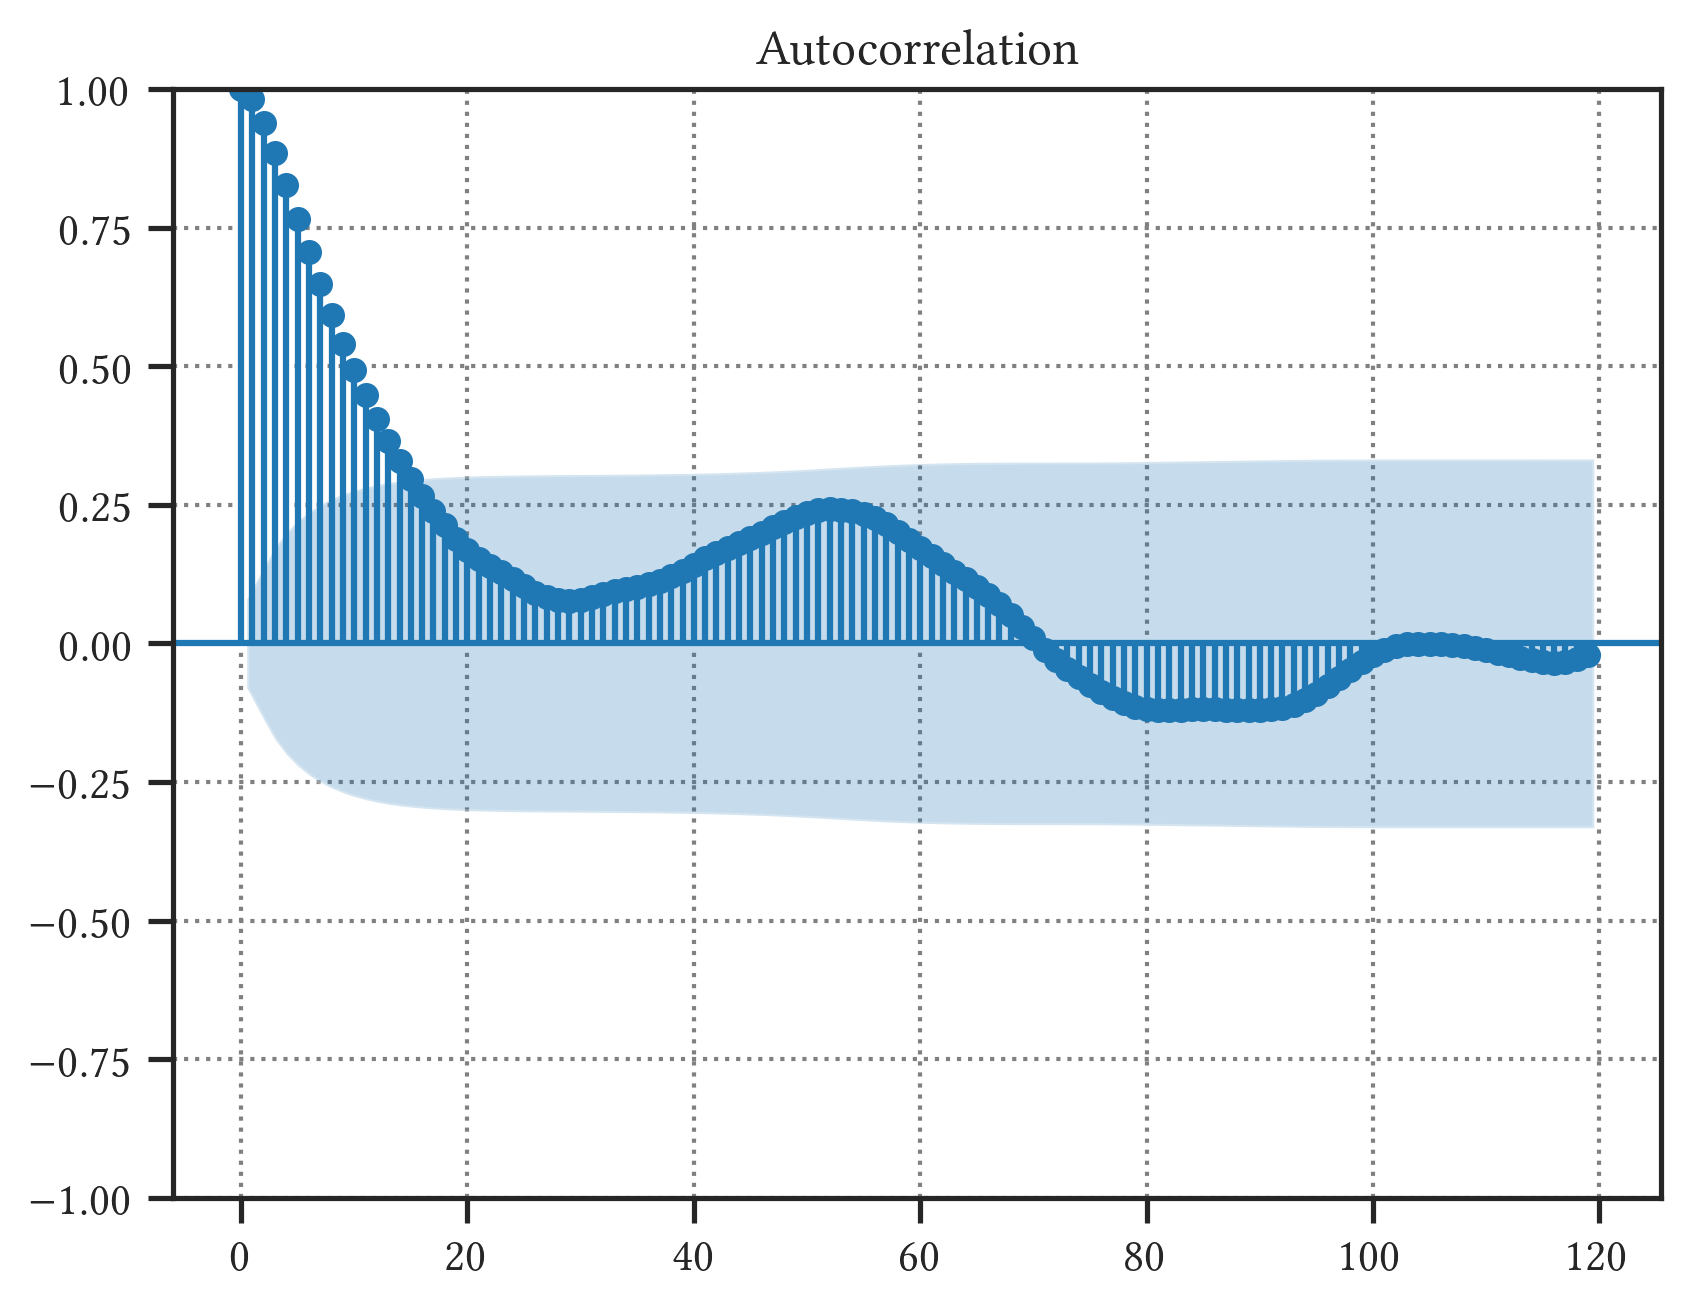

In [70]:
plot_acf(y_tr.numpy(), lags=np.arange(0, 120))
print()

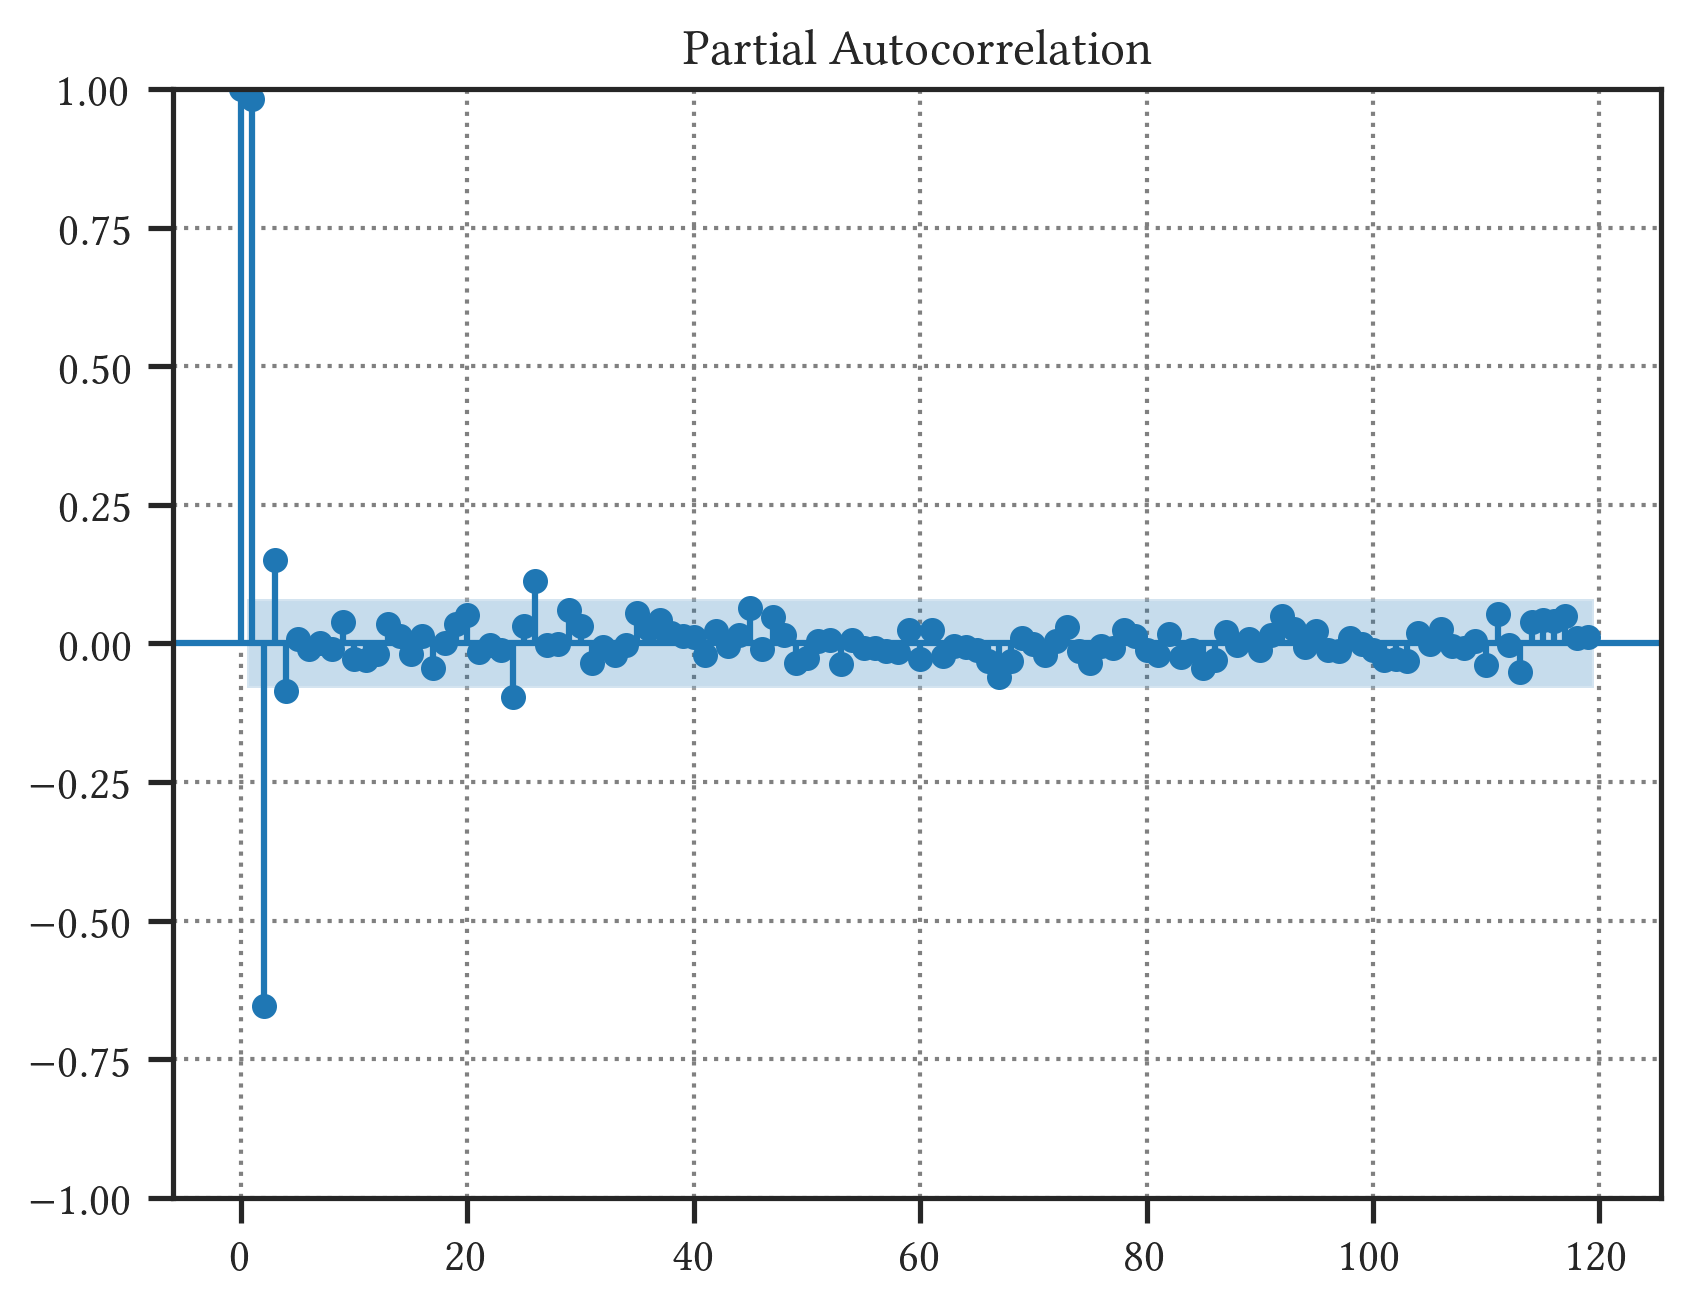

In [71]:
plot_pacf(y_tr.numpy(), lags=np.arange(0, 120))
print()

In [72]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series, autolag=None, maxlag=200)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

check_stationarity(y_tr.numpy())

ADF Statistic: -0.992053
p-value: 0.756152
Critical Values:
	1%: -3.447
	5%: -2.869
	10%: -2.571
Non-stationary


In [73]:
class SmoothGPModel(gpytorch.models.ExactGP):
    def __init__(self, x_tr, y_tr, likelihood):
        super(SmoothGPModel, self).__init__(x_tr, y_tr, likelihood)
        
        self.mean_module = gpytorch.means.ConstantMean()
        
        self.cov_module = gpytorch.kernels.AdditiveKernel(
            gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel()),
            gpytorch.kernels.ScaleKernel(gpytorch.kernels.PeriodicKernel()),
        )

    def forward(self, x):
        x_mean = self.mean_module(x)
        x_cov = self.cov_module(x)
        
        return gpytorch.distributions.MultivariateNormal(x_mean, x_cov)

In [74]:
# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood(
    noise_constraint = gpytorch.constraints.Positive(),
    noise_prior = gpytorch.priors.NormalPrior(1e-2, 1),
)
model = SmoothGPModel(x_tr, y_tr, likelihood)

# Initialize kernels
model.cov_module.kernels[0].base_kernel.initialize(
    lengthscale = torch.tensor(50)
)

model.cov_module.kernels[1].base_kernel.initialize(
    lengthscale = torch.tensor(50.),
    period_length = torch.tensor(95.),
)

model.double()

SmoothGPModel(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): NormalPrior()
      (raw_noise_constraint): Positive()
    )
  )
  (mean_module): ConstantMean()
  (cov_module): AdditiveKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): RBFKernel(
          (raw_lengthscale_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
      (1): ScaleKernel(
        (base_kernel): PeriodicKernel(
          (raw_lengthscale_constraint): Positive()
          (raw_period_length_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
    )
  )
)

In [75]:
# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam([{'params': model.parameters()},], lr=1e-1)

mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

max_iter = 200
losses = []

p_bar = tqdm(range(max_iter))
for i in p_bar:
    optimizer.zero_grad()
    output = model(x_tr)
    loss = -mll(output, y_tr)
    losses += [loss.item()]
    loss.backward()

    p_status = f"{i + 1:3d}/{max_iter:3d} Loss: {loss.item():.3f}"
    p_bar.set_description(p_status)
    
    optimizer.step()

  0%|          | 0/200 [00:00<?, ?it/s]

In [76]:
# Model parameters
for param_name, param in model.named_parameters():
    print(f"{param_name:42} \t {param.item()}")

likelihood.noise_covar.raw_noise           	 -17.230377734487575
mean_module.raw_constant                   	 0.0027375209265408395
cov_module.kernels.0.raw_outputscale       	 -15.784337621043601
cov_module.kernels.0.base_kernel.raw_lengthscale 	 61.199299298939856
cov_module.kernels.1.raw_outputscale       	 -10.008691707356629
cov_module.kernels.1.base_kernel.raw_lengthscale 	 56.30139688420464
cov_module.kernels.1.base_kernel.raw_period_length 	 105.45144771019633


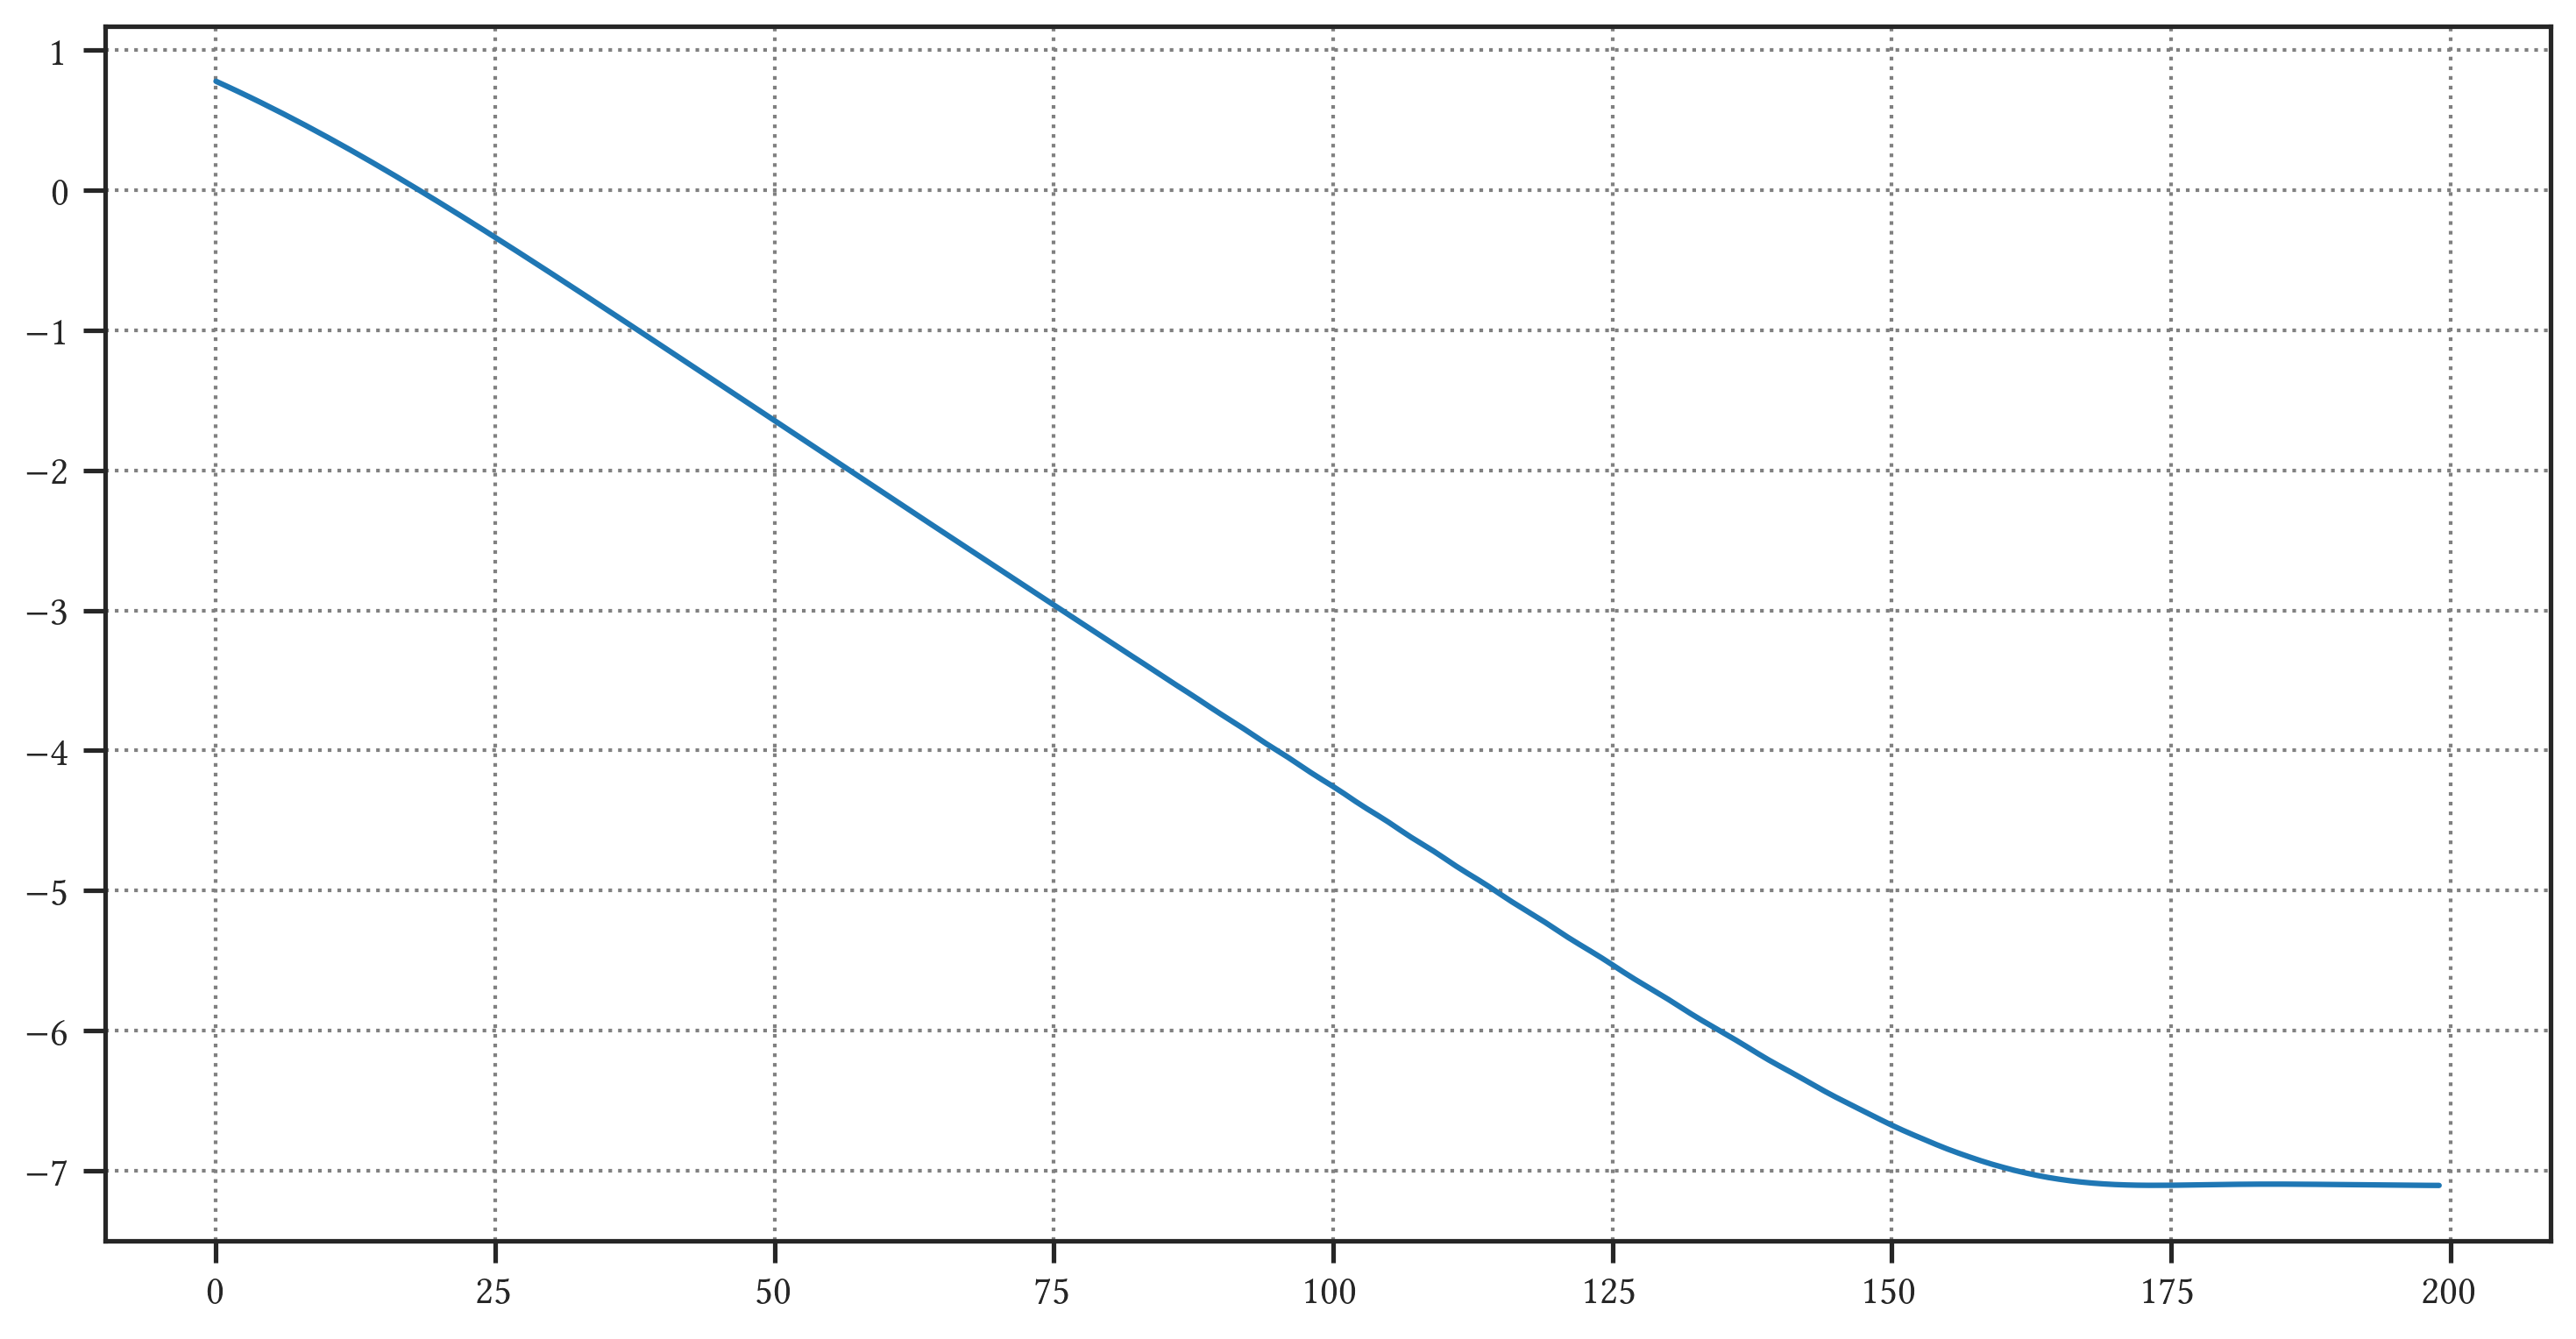

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(np.arange(len(losses)), losses)

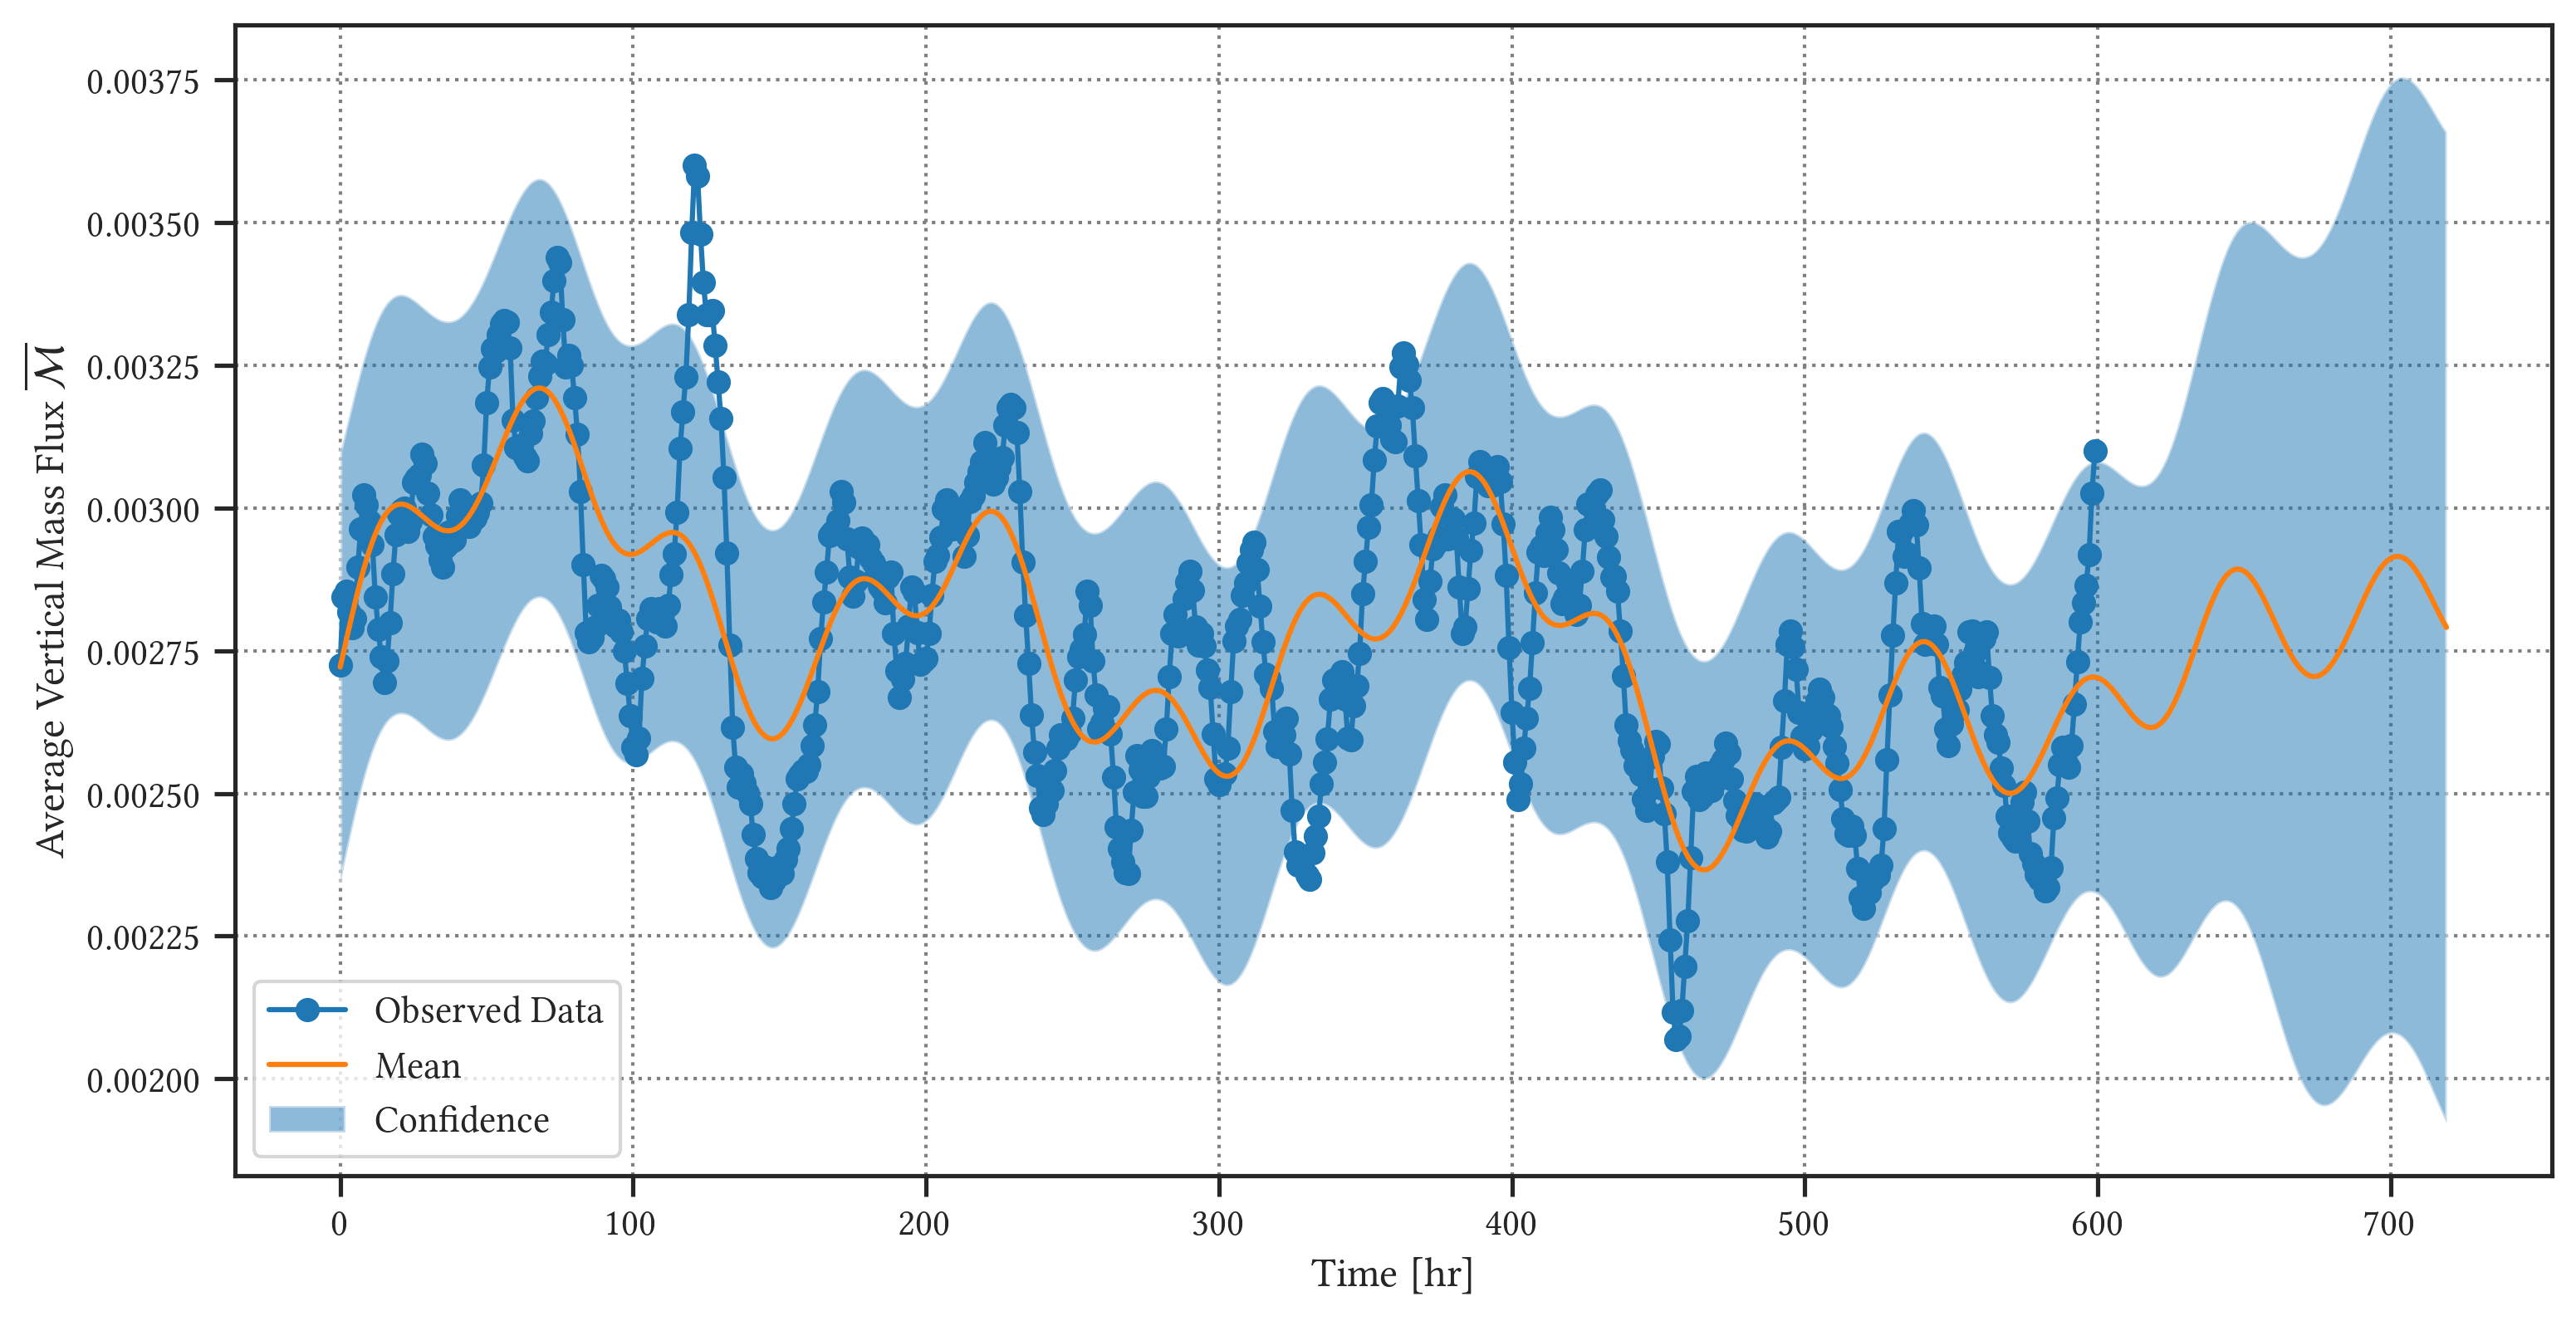

In [78]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad():
    x_test = torch.arange(len(x_tr) + 120, dtype=torch.double)
    observed = likelihood(model(x_test))

with torch.no_grad():
    # Initialize plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    lower, upper = observed.confidence_region()

    ax.plot(x_tr.numpy(), y_tr.numpy(), 'o-')
    ax.plot(x_test.numpy(), observed.mean.numpy())
    ax.fill_between(x_test.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)

    ax.set_xlabel("Time [hr]")
    ax.set_ylabel("Average Vertical Mass Flux $\overline{\mathcal{M}}$")

    ax.legend(['Observed Data', 'Mean', 'Confidence'])

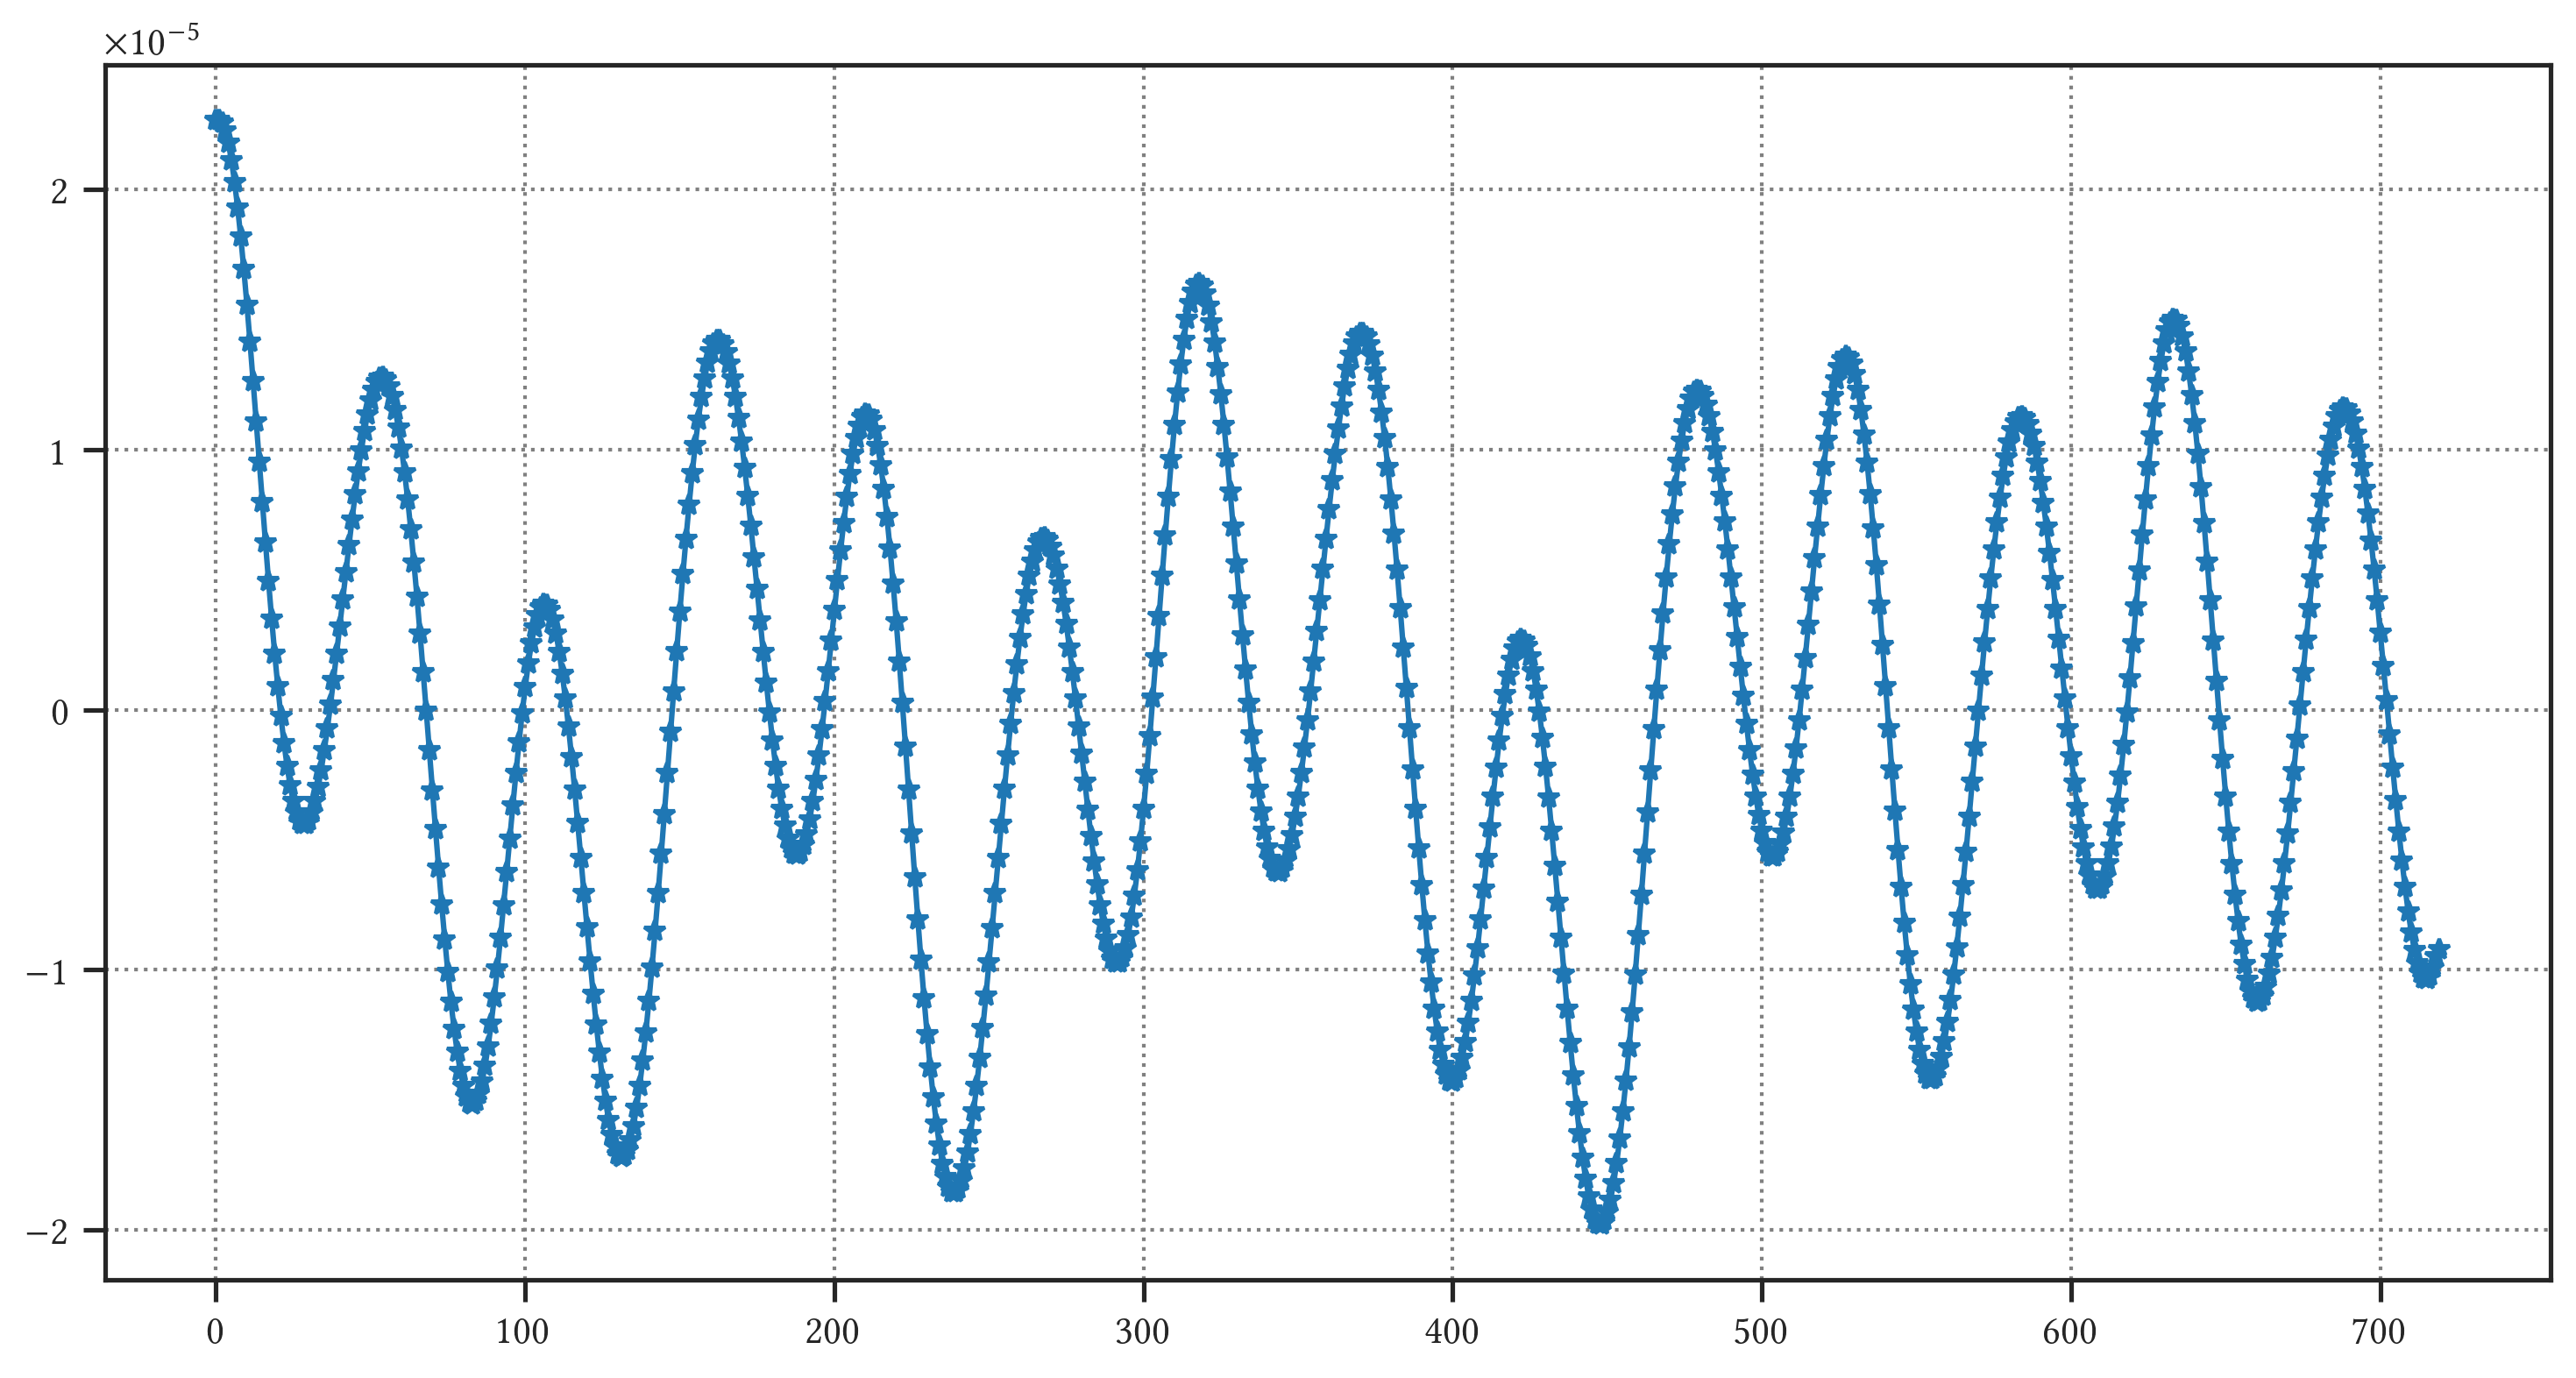

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x_test.numpy(), np.gradient(observed.mean.numpy()), '*-')

y_tr = torch.tensor(np.gradient(observed.mean), dtype=torch.double)
x_tr = torch.tensor(np.arange(len(y_tr)), dtype=torch.double)

In [80]:
check_stationarity(y_tr.numpy())

ADF Statistic: -4.871825
p-value: 0.000040
Critical Values:
	1%: -3.443
	5%: -2.867
	10%: -2.570
Stationary
